In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

In [5]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/data/dataspam.csv')
df.head()

,text,class
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


In [6]:
# Check data
print(df['text'][0])
print(df['class'].unique())
print(df['class'].isna().sum())
print(df.shape)


From ilug-admin@linux.ie Mon Jul 29 11:28:02 2002 Return-Path: <ilug-admin@linux.ie> Delivered-To: yyyy@localhost.netnoteinc.com Received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (Postfix) with ESMTP id A13D94414F for <jm@localhost>; Mon, 29 Jul 2002 06:25:11 -0400 (EDT) Received: from phobos [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for jm@localhost (single-drop); Mon, 29 Jul 2002 11:25:11 +0100 (IST) Received: from lugh.tuatha.org (root@lugh.tuatha.org [194.125.145.45]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g6RHn7i17130 for <jm-ilug@jmason.org>; Sat, 27 Jul 2002 18:49:07 +0100 Received: from lugh (root@localhost [127.0.0.1]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id SAA25016; Sat, 27 Jul 2002 18:45:03 +0100 X-Authentication-Warning: lugh.tuatha.org: Host root@localhost [127.0.0.1] claimed to be lugh Received: from mail1.mail.iol.ie (mail1.mail.iol.ie [194.125.2.192]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id SAA24977 fo

In [8]:
# Clean data
df = df.dropna(subset=['class'])
print(df.shape)

# Standardize labels
df['class'] = df['class'].astype(str).str.lower().replace({'1': 'phishing', '0': 'not phishing'})
print(df.groupby('class').count())

(5787, 2)
              text
class             
not phishing  3896
phishing      1891


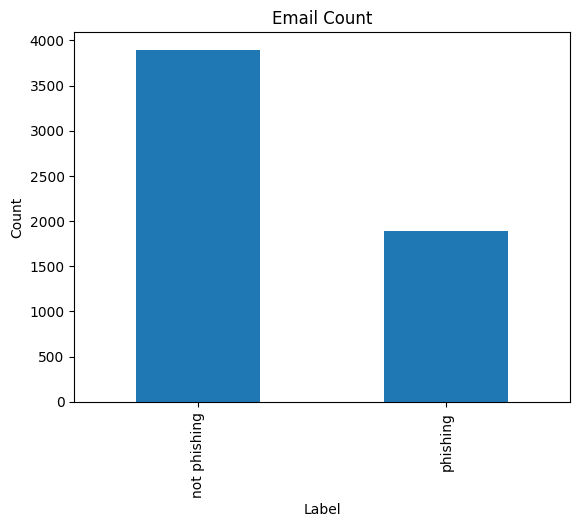

In [9]:
# Visualize class distribution
label_counts = df['class'].value_counts()
label_counts.plot(kind='bar')
plt.title('Email Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [10]:
# English text cleaning function
def clean_english_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters
    text = re.sub(r'[^\w\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Convert to lowercase
    text = text.lower()
    return text

In [11]:
df['Cleaned Text'] = df['text'].apply(clean_english_text)
print(df[['text', 'Cleaned Text']].head())

# Convert labels to binary
df['Label'] = df['class'].apply(lambda x: 1 if x == 'phishing' else 0)
print(df.head())

                                                text  \
0  From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...   
1  From gort44@excite.com Mon Jun 24 17:54:21 200...   
2  From fork-admin@xent.com Mon Jul 29 11:39:57 2...   
3  From dcm123@btamail.net.cn Mon Jun 24 17:49:23...   
4  From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...   

                                        Cleaned Text  
0  from mon jul 29 11 28 02 2002 return path deli...  
1  from mon jun 24 17 54 21 2002 return path deli...  
2  from mon jul 29 11 39 57 2002 return path deli...  
3  from mon jun 24 17 49 23 2002 return path deli...  
4  from mon aug 19 11 02 47 2002 return path deli...  
                                                text         class  \
0  From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...  not phishing   
1  From gort44@excite.com Mon Jun 24 17:54:21 200...      phishing   
2  From fork-admin@xent.com Mon Jul 29 11:39:57 2...      phishing   
3  From dcm123@btamail.net.cn Mon Jun 24 17:49:23... 

In [12]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df['Cleaned Text'], df['Label'], test_size=0.2, random_state=42)

# Load English BERT tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [13]:
def encode_texts(texts, tokenizer, max_length=128):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="tf"
    )

X_train_encoded = encode_texts(X_train, tokenizer)
X_test_encoded = encode_texts(X_test, tokenizer)

y_train = tf.convert_to_tensor(y_train.tolist())
y_test = tf.convert_to_tensor(y_test.tolist())

In [14]:
# Load English BERT model
model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
# Train model
history = model.fit(X_train_encoded['input_ids'], y_train, epochs=3, batch_size=16, validation_split=0.1)

Epoch 1/3
261/261 [==============================] - 6746s 25s/step - loss: 0.2437 - accuracy: 0.9186 - val_loss: 0.1655 - val_accuracy: 0.9460
Epoch 2/3
261/261 [==============================] - 6622s 25s/step - loss: 0.1199 - accuracy: 0.9599 - val_loss: 0.0958 - val_accuracy: 0.9590
Epoch 3/3
261/261 [==============================] - 6541s 25s/step - loss: 0.1017 - accuracy: 0.9642 - val_loss: 0.0937 - val_accuracy: 0.9611


In [17]:
# Evaluate model
y_pred = model.predict(X_test_encoded['input_ids'])
y_pred_labels = tf.argmax(y_pred.logits, axis=1)

# Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred_labels))
print("Accuracy:", accuracy_score(y_test, y_pred_labels))

37/37 [==============================] - 582s 15s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       789
           1       0.99      0.89      0.94       369

    accuracy                           0.96      1158
   macro avg       0.97      0.94      0.96      1158
weighted avg       0.96      0.96      0.96      1158

Accuracy: 0.9628670120898101
37/37 [==============================] - 571s 15s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       789
           1       0.99      0.89      0.94       369

    accuracy                           0.96      1158
   macro avg       0.97      0.94      0.96      1158
weighted avg       0.96      0.96      0.96      1158

Accuracy: 0.9628670120898101


In [18]:
# Save model
model.save_pretrained("/content/drive/MyDrive/en_bert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/en_bert_tokenizer")

('/content/drive/MyDrive/en_bert_tokenizer/tokenizer_config.json',
 '/content/drive/MyDrive/en_bert_tokenizer/special_tokens_map.json',
 '/content/drive/MyDrive/en_bert_tokenizer/vocab.txt',
 '/content/drive/MyDrive/en_bert_tokenizer/added_tokens.json',
 '/content/drive/MyDrive/en_bert_tokenizer/tokenizer.json')

In [19]:
# Load saved model and tokenizer
model = TFAutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/en_bert_model")
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/en_bert_tokenizer")

Some layers from the model checkpoint at /content/drive/MyDrive/en_bert_model were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/drive/MyDrive/en_bert_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


In [20]:
def predict_text(text):
    # Clean the input text first
    cleaned_text = clean_english_text(text)
    inputs = tokenizer(cleaned_text, return_tensors="tf", padding=True, truncation=True, max_length=128)
    outputs = model(inputs['input_ids'])
    predictions = tf.argmax(outputs.logits, axis=1)
    return "Phishing" if predictions.numpy()[0] == 1 else "Not Phishing"

In [26]:
# Test model
sample_texts = [
"Received: from dallas.net (ultra1.dallas.net [204.215.60.15]) by linux.midrange.com (8.11.6/8.11.6) with ESMTP id g6OBc3e03139 for <gibbs@midrange.com>; Wed, 24 Jul 2002 06:38:03 -0500 Received: from larry.catalog.com (larry.catalog.com [209.217.36.10]) by dallas.net (8.12.2/8.12.2) with ESMTP id g6OBV7mv005342; Wed, 24 Jul 2002 06:31:08 -0500 (CDT) Received: (from spiritweb@localhost) by larry.catalog.com (8.12.0.Beta19/8.12.0.Beta19) id g6OBUJcd019533; Wed, 24 Jul 2002 06:30:19 -0500 (CDT) Date: Wed, 24 Jul 2002 06:30:19 -0500 (CDT) Message-Id: <200207241130.g6OBUJcd019533@larry.catalog.com> To: gibbs@koalas.com, gibbs@mcs.com, gibbs@mercury.mcs.net, gibbs@midrange.com, gibbs@nternet.com, gibbs@rcn.com, gibbs@sprintmail.com, gibbs_donna@msn.com, gibbs_household@bigpond.com, gibbs_raetz@msn.com From: YourPeach21@hotmail.com () Subject: Limited Time Offer For A FREE Membership! X-Status: X-Keywords: Below is the result of your feedback form. It was submitted by (YourPeach21@hotmail.com) on Wednesday, July 24, 2002 at 06:30:19 --------------------------------------------------------------------------- :: For a limited time you can get a 100% FREE membership to the best sites on the internet. No telling how long this limited time offer will last <a href=""http://rd.yahoo.com/dir/?http://members.lycos.co.uk/yourselected/winner.htm"">Act Fast!</a>If You Would Like To Be Removed Then <a href=""mailto:remove_me123@hotmail.com"">remove</a> ---------------------------------------------------------------------------",
 "From rssfeeds@jmason.org Thu Sep 26 16:33:57 2002 Return-Path: <rssfeeds@spamassassin.taint.org> Delivered-To: yyyy@localhost.spamassassin.taint.org Received: from localhost (jalapeno [127.0.0.1]) by jmason.org (Postfix) with ESMTP id 2E3F016F03 for <jm@localhost>; Thu, 26 Sep 2002 16:33:57 +0100 (IST) Received: from jalapeno [127.0.0.1] by localhost with IMAP (fetchmail-5.9.0) for jm@localhost (single-drop); Thu, 26 Sep 2002 16:33:57 +0100 (IST) Received: from dogma.slashnull.org (localhost [127.0.0.1]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g8QFSBg24408 for <jm@jmason.org>; Thu, 26 Sep 2002 16:28:11 +0100 Message-Id: <200209261528.g8QFSBg24408@dogma.slashnull.org> To: yyyy@spamassassin.taint.org From: boingboing <rssfeeds@spamassassin.taint.org> Subject: Gearheads and bunnyhuggers in the OED Date: Thu, 26 Sep 2002 15:28:11 -0000 Content-Type: text/plain; encoding=utf-8 URL: http://boingboing.net/#85494694 Date: Not supplied Some of the words in the new shorter Oxford English Dictionary: Asylum seeker, economic migrant, bed-blocking, and stakeholder pension reflect the serious side of life; bunny-hugger (a conservationist or animal lover), chick flick (a film appealing to women), gearhead (a car enthusiast), and Grinch (a spoilsport or killjoy) are entries in a more light-hearted vein. Several entries are testaments to the popularity of science fiction, among them Tardis from the TV series Doctor Who, Jedi from Star Wars, and Klingon from Star Trek. Link[1] Discuss[2] (_Thanks, Mark!_) [1] http://www.askoxford.com/worldofwords/wordfrom/shorter/ [2] http://www.quicktopic.com/boing/H/2tC5tCQqCRD3b"
]

for text in sample_texts:
    print("Email:", text)
    print("Prediction:", predict_text(text))
    print("---")

Email: Received: from dallas.net (ultra1.dallas.net [204.215.60.15]) by linux.midrange.com (8.11.6/8.11.6) with ESMTP id g6OBc3e03139 for <gibbs@midrange.com>; Wed, 24 Jul 2002 06:38:03 -0500 Received: from larry.catalog.com (larry.catalog.com [209.217.36.10]) by dallas.net (8.12.2/8.12.2) with ESMTP id g6OBV7mv005342; Wed, 24 Jul 2002 06:31:08 -0500 (CDT) Received: (from spiritweb@localhost) by larry.catalog.com (8.12.0.Beta19/8.12.0.Beta19) id g6OBUJcd019533; Wed, 24 Jul 2002 06:30:19 -0500 (CDT) Date: Wed, 24 Jul 2002 06:30:19 -0500 (CDT) Message-Id: <200207241130.g6OBUJcd019533@larry.catalog.com> To: gibbs@koalas.com, gibbs@mcs.com, gibbs@mercury.mcs.net, gibbs@midrange.com, gibbs@nternet.com, gibbs@rcn.com, gibbs@sprintmail.com, gibbs_donna@msn.com, gibbs_household@bigpond.com, gibbs_raetz@msn.com From: YourPeach21@hotmail.com () Subject: Limited Time Offer For A FREE Membership! X-Status: X-Keywords: Below is the result of your feedback form. It was submitted by (YourPeach21@hotm